In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
#Apple stock data
df=yf.download("AAPL",
               start="2021-06-09",
               end="2026-06-09")
#save to CSV
df.to_csv("AAPL.csv")
print(df.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2021-06-09  123.920212  124.524561  123.325613  123.998194  56877900
2021-06-10  122.925957  124.953442  122.760251  123.812977  71186400
2021-06-11  124.134644  124.222375  122.916204  123.335347  53522400
2021-06-14  127.185623  127.244106  123.861723  124.592787  96906500
2021-06-15  126.366852  127.302620  126.123164  126.659280  62746300


In [3]:
df.columns = df.columns.get_level_values(0)

print(df.head())

Price            Close        High         Low        Open    Volume
Date                                                                
2021-06-09  123.920212  124.524561  123.325613  123.998194  56877900
2021-06-10  122.925957  124.953442  122.760251  123.812977  71186400
2021-06-11  124.134644  124.222375  122.916204  123.335347  53522400
2021-06-14  127.185623  127.244106  123.861723  124.592787  96906500
2021-06-15  126.366852  127.302620  126.123164  126.659280  62746300


In [4]:
df.to_csv("apple_stock.csv")

DATA EXPLORATION

In [5]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-06-09,123.920212,124.524561,123.325613,123.998194,56877900
2021-06-10,122.925957,124.953442,122.760251,123.812977,71186400
2021-06-11,124.134644,124.222375,122.916204,123.335347,53522400
2021-06-14,127.185623,127.244106,123.861723,124.592787,96906500
2021-06-15,126.366852,127.302620,126.123164,126.659280,62746300


In [6]:
df.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-06-02,315.200012,315.450012,306.690002,307.459991,44534700
2026-06-03,310.260010,316.940002,308.850006,314.179993,50836700
2026-06-04,311.230011,313.540009,309.649994,313.230011,44869100
2026-06-05,307.339996,315.170013,307.149994,312.859985,65310500
2026-06-08,301.540009,317.399994,301.170013,308.739990,77949100


In [7]:
df.describe()

Price,Close,High,Low,Open,Volume
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,191.716372,193.602675,189.652022,191.512974,6.535338e+07
std,44.022089,44.363709,43.694422,44.018307,2.818017e+07
min,122.925957,124.222375,122.097746,123.335347,1.791060e+07
25%,154.339836,156.920501,151.926131,154.870495,4.615660e+07
50%,180.775665,182.657836,179.321280,180.674159,5.780870e+07
75%,225.504387,227.423457,223.152922,225.535491,7.759175e+07
max,315.200012,317.399994,309.649994,314.179993,3.186799e+08


In [8]:
df.dtypes

Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [9]:
df.shape

(1255, 5)

In [10]:
#Information check
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-06-09 to 2026-06-08
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1255 non-null   float64
 1   High    1255 non-null   float64
 2   Low     1255 non-null   float64
 3   Open    1255 non-null   float64
 4   Volume  1255 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [11]:
#checking for missing values
df.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [12]:
#Checking for duplications
df.duplicated().sum()

np.int64(0)

In [13]:
#Checking date range
print("Start Date:", df.index.min())
print("End Date:", df.index.max())

Start Date: 2021-06-09 00:00:00
End Date: 2026-06-08 00:00:00


In [14]:
#wondering why the columns from shape says 5
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [15]:
#Number of trading days
len(df)

1255

In [16]:
#Check unique years
df.index.year.unique()

Index([2021, 2022, 2023, 2024, 2025, 2026], dtype='int32', name='Date')

In [17]:
#Sample random rows
df.sample(5)

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-02-05,230.994171,231.192898,226.820838,227.079182,39620300
2023-07-11,185.479706,186.682840,184.020172,186.544776,46638100
2025-10-20,261.500183,263.634161,254.908845,255.168106,90483000
2022-04-04,174.671799,174.720746,170.756269,170.883528,76468400
2021-12-02,160.097839,160.528002,154.271131,155.190112,136739200


In [18]:
#Correlatin between numerical columns
df.corr(numeric_only='True')

Price,Close,High,Low,Open,Volume
Price,,,,,
Close,1.000000,0.999130,0.999145,0.998049,-0.446811
High,0.999130,1.000000,0.998825,0.999010,-0.434313
Low,0.999145,0.998825,1.000000,0.999141,-0.459620
Open,0.998049,0.999010,0.999141,1.000000,-0.449563
Volume,-0.446811,-0.434313,-0.459620,-0.449563,1.000000


*DATASET OVERVIEW*

This dataset contains records of five years of historical apple stock market data downloaded using yfinance yfinance library, each row represents one trading day which includes the information on the stock price opening, its closing for the day, the high price for that day,the lowest fo that day and the trade volume for the day. This dataset is a datetimeindex which makes it well suited for time analysis, the initial exploration is to understand the dataset's struture,identify missing values,inspect data types and summarize statistical discription for each variable.

DATA CLEANING AND PRE-PROCESSING

In [19]:
#Check for duplicates
df.duplicated().sum()

np.int64(0)

In [20]:
df=df.drop_duplicates()

In [21]:
#Check for missing values
df.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

No row removal or filling in was neccessary because no missing values were found. 

DATASET TRANSFORMATION

In [22]:
#Filtering and Sorting
df=df.sort_index()

In [23]:
#filter from year 2024 
df_2024= df.loc['2024':]
print(df_2024)

Price            Close        High         Low        Open    Volume
Date                                                                
2024-01-02  183.562180  186.330843  181.831767  185.055273  82488700
2024-01-03  182.187729  183.799489  181.376900  182.158066  58414500
2024-01-04  179.873947  181.040733  178.855477  180.111251  71983600
2024-01-05  179.152084  180.714402  178.153394  179.953031  62379700
2024-01-08  183.483093  183.522654  179.468538  180.051930  59144500
...                ...         ...         ...         ...       ...
2026-06-02  315.200012  315.450012  306.690002  307.459991  44534700
2026-06-03  310.260010  316.940002  308.850006  314.179993  50836700
2026-06-04  311.230011  313.540009  309.649994  313.230011  44869100
2026-06-05  307.339996  315.170013  307.149994  312.859985  65310500
2026-06-08  301.540009  317.399994  301.170013  308.739990  77949100

[610 rows x 5 columns]


In [24]:
#Group yearly
Yearly = df.groupby(df.index.year).mean(numeric_only='True')

In [25]:
print(Yearly)

Price       Close        High         Low        Open        Volume
Date                                                               
2021   146.737946  147.973418  145.207795  146.404496  8.376460e+07
2022   151.805452  153.837705  149.703618  151.773849  8.791038e+07
2023   170.194613  171.484992  168.649334  169.906604  5.922355e+07
2024   205.457392  207.147182  203.484609  205.205687  5.710678e+07
2025   231.349892  233.833558  228.745397  231.156008  5.417578e+07
2026   270.455784  273.325861  267.601416  270.313080  4.768656e+07


In [26]:
#Average fof monthly lows
Monthly_Low = df['Low'].resample('ME').mean()
print(Monthly_Low)

Date
2021-06-30    127.128358
2021-07-31    139.914498
2021-08-31    143.333176
2021-09-30    143.718450
2021-10-31    140.530409
                 ...    
2026-02-28    265.795046
2026-03-31    252.244420
2026-04-30    261.196495
2026-05-31    294.193376
2026-06-30    306.421666
Freq: ME, Name: Low, Length: 61, dtype: float64


In [27]:
#Average Yearly closing price
Yearly_Close= df['Close'].resample('YE').mean()
print(Yearly_Close)

Date
2021-12-31    146.737946
2022-12-31    151.805452
2023-12-31    170.194613
2024-12-31    205.457392
2025-12-31    231.349892
2026-12-31    270.455784
Freq: YE-DEC, Name: Close, dtype: float64


In [28]:
#Calculated columns
df['Daily Price Change'] = df['Close'] - df['Open']
print(df)

Price            Close        High         Low        Open    Volume  \
Date                                                                   
2021-06-09  123.920212  124.524561  123.325613  123.998194  56877900   
2021-06-10  122.925957  124.953442  122.760251  123.812977  71186400   
2021-06-11  124.134644  124.222375  122.916204  123.335347  53522400   
2021-06-14  127.185623  127.244106  123.861723  124.592787  96906500   
2021-06-15  126.366852  127.302620  126.123164  126.659280  62746300   
...                ...         ...         ...         ...       ...   
2026-06-02  315.200012  315.450012  306.690002  307.459991  44534700   
2026-06-03  310.260010  316.940002  308.850006  314.179993  50836700   
2026-06-04  311.230011  313.540009  309.649994  313.230011  44869100   
2026-06-05  307.339996  315.170013  307.149994  312.859985  65310500   
2026-06-08  301.540009  317.399994  301.170013  308.739990  77949100   

Price       Daily Price Change  
Date                          

In [29]:
#Percentage of price change
df['Percentage Price Change'] = ((df['Close'] - df['Open']) / df['Open']) * 100
print(df)

Price            Close        High         Low        Open    Volume  \
Date                                                                   
2021-06-09  123.920212  124.524561  123.325613  123.998194  56877900   
2021-06-10  122.925957  124.953442  122.760251  123.812977  71186400   
2021-06-11  124.134644  124.222375  122.916204  123.335347  53522400   
2021-06-14  127.185623  127.244106  123.861723  124.592787  96906500   
2021-06-15  126.366852  127.302620  126.123164  126.659280  62746300   
...                ...         ...         ...         ...       ...   
2026-06-02  315.200012  315.450012  306.690002  307.459991  44534700   
2026-06-03  310.260010  316.940002  308.850006  314.179993  50836700   
2026-06-04  311.230011  313.540009  309.649994  313.230011  44869100   
2026-06-05  307.339996  315.170013  307.149994  312.859985  65310500   
2026-06-08  301.540009  317.399994  301.170013  308.739990  77949100   

Price       Daily Price Change  Percentage Price Change  
Date 

In [30]:
#Daily Price range
df['Daily Range'] = df['High'] - df['Low']
print(df)

Price            Close        High         Low        Open    Volume  \
Date                                                                   
2021-06-09  123.920212  124.524561  123.325613  123.998194  56877900   
2021-06-10  122.925957  124.953442  122.760251  123.812977  71186400   
2021-06-11  124.134644  124.222375  122.916204  123.335347  53522400   
2021-06-14  127.185623  127.244106  123.861723  124.592787  96906500   
2021-06-15  126.366852  127.302620  126.123164  126.659280  62746300   
...                ...         ...         ...         ...       ...   
2026-06-02  315.200012  315.450012  306.690002  307.459991  44534700   
2026-06-03  310.260010  316.940002  308.850006  314.179993  50836700   
2026-06-04  311.230011  313.540009  309.649994  313.230011  44869100   
2026-06-05  307.339996  315.170013  307.149994  312.859985  65310500   
2026-06-08  301.540009  317.399994  301.170013  308.739990  77949100   

Price       Daily Price Change  Percentage Price Change  Daily 

In [31]:
#rounding off to 2 decimal place
df= df.round(2)
print(df)

Price        Close    High     Low    Open    Volume  Daily Price Change  \
Date                                                                       
2021-06-09  123.92  124.52  123.33  124.00  56877900               -0.08   
2021-06-10  122.93  124.95  122.76  123.81  71186400               -0.89   
2021-06-11  124.13  124.22  122.92  123.34  53522400                0.80   
2021-06-14  127.19  127.24  123.86  124.59  96906500                2.59   
2021-06-15  126.37  127.30  126.12  126.66  62746300               -0.29   
...            ...     ...     ...     ...       ...                 ...   
2026-06-02  315.20  315.45  306.69  307.46  44534700                7.74   
2026-06-03  310.26  316.94  308.85  314.18  50836700               -3.92   
2026-06-04  311.23  313.54  309.65  313.23  44869100               -2.00   
2026-06-05  307.34  315.17  307.15  312.86  65310500               -5.52   
2026-06-08  301.54  317.40  301.17  308.74  77949100               -7.20   

Price      

*TIME SERIES ANALYSIS*

This is the study of how data changes overtime.

In [32]:
# 1. Date and Time Manipulation : Extracting useful pieces to answer questions.
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day_name()
df['Month_Name'] = df.index.month_name()
df['Quarter'] = df.index.quarter
df.head()

Price,Close,High,Low,Open,Volume,Daily Price Change,Percentage Price Change,Daily Range,Year,Month,Day,Month_Name,Quarter
Date,,,,,,,,,,,,,
2021-06-09,123.92,124.52,123.33,124.00,56877900,-0.08,-0.06,1.20,2021,6,Wednesday,June,2
2021-06-10,122.93,124.95,122.76,123.81,71186400,-0.89,-0.72,2.19,2021,6,Thursday,June,2
2021-06-11,124.13,124.22,122.92,123.34,53522400,0.80,0.65,1.31,2021,6,Friday,June,2
2021-06-14,127.19,127.24,123.86,124.59,96906500,2.59,2.08,3.38,2021,6,Monday,June,2
2021-06-15,126.37,127.30,126.12,126.66,62746300,-0.29,-0.23,1.18,2021,6,Tuesday,June,2


In [33]:
# 2. Trend Analysis: Identifying trends numerically.
#Question; How does price of the stocks change overtime? doing this comparing the first and last price at the close of the market through time.
First_Price = df['Close'].iloc[0]
Last_Price = df['Close'].iloc[-1]
print(f"First Closing Price: ${First_Price: 2f}")
print(f"Last Closing Price: ${Last_Price: 2f}")


First Closing Price: $ 123.920000
Last Closing Price: $ 301.540000


From 2021 to 2026

In [34]:
# 3. How much is the growth over the years
Growth = ((Last_Price - First_Price)/ First_Price)*100
print(f"Total_Growth:{Growth:2f}%")

Total_Growth:143.334409%


In [35]:
# 4. What is the average closing price by year
Average_Price_Yearly = df.groupby('Year')['Close'].mean()
print(Average_Price_Yearly)

Year
2021    146.737847
2022    151.805219
2023    170.194360
2024    205.457659
2025    231.349720
2026    270.456111
Name: Close, dtype: float64


In [36]:
# 5. Highest closing price each year
Highest_Price = df.groupby('Year')['Close'].max()
print(Highest_Price)

Year
2021    176.30
2022    177.94
2023    195.89
2024    257.38
2025    285.66
2026    315.20
Name: Close, dtype: float64


In [37]:
# 6. Highest closing stock price each month
Highest_Monthly_Price = df.groupby('Month_Name')['Close'].max().sort_index()
print(Highest_Monthly_Price)

Month_Name
April        273.18
August       232.67
December     285.66
February     277.60
January      270.51
July         232.80
June         315.20
March        264.48
May          312.51
November     278.33
October      270.63
September    256.15
Name: Close, dtype: float64


In [38]:
# 7. What is the lowest closing stock price each year
Low_Price = df.groupby('Year')['Close'].min()
print(Low_Price)

Year
2021    122.93
2022    123.94
2023    122.93
2024    163.36
2025    171.51
2026    246.24
Name: Close, dtype: float64


In [39]:
# 8. What is the annual growth?
# using resample
year_end = df['Close'].resample('YE').last()

annual_growth = year_end.pct_change() * 100

print(annual_growth)

Date
2021-12-31          NaN
2022-12-31   -26.405530
2023-12-31    49.013776
2024-12-31    30.701754
2025-12-31     9.054374
2026-12-31    11.121757
Freq: YE-DEC, Name: Close, dtype: float64


In [40]:
# What are the average daily returns
daily_return = df['Close'].pct_change() * 100

print(daily_return.describe())

count    1254.000000
mean        0.085842
std         1.731254
min        -9.245207
25%        -0.760021
50%         0.112243
75%         0.965133
max        15.328552
Name: Close, dtype: float64


In [41]:
# What is the average monthly returns
Monthly_Average = df['Close'].resample('ME').mean()
print(Monthly_Average.head())

Date
2021-06-30    128.404375
2021-07-31    141.473810
2021-08-31    144.614545
2021-09-30    144.778571
2021-10-31    142.100000
Freq: ME, Name: Close, dtype: float64


In [42]:
monthly_return = df['Close'].resample('ME').last().pct_change() * 100

print(monthly_return.head())

Date
2021-06-30         NaN
2021-07-31    6.501873
2021-08-31    4.248136
2021-09-30   -6.807448
2021-10-31    5.871281
Freq: ME, Name: Close, dtype: float64


*FEATURED ENGINEERING*

In [43]:
#Rolling ages
df['7-Day MA'] = df['Close'].rolling(window=7).mean()

df['30-Day MA'] = df['Close'].rolling(window=30).mean()

df[['Close', '7-Day MA', '30-Day MA']].tail()

Price,Close,7-Day MA,30-Day MA
Date,,,
2026-06-02,315.20,310.582857,291.082000
2026-06-03,310.26,310.788571,292.559667
2026-06-04,311.23,311.202857,293.836667
2026-06-05,307.34,310.701429,294.975333
2026-06-08,301.54,309.134286,295.999667


In [44]:
# Percentage analysis
# Daily percentage change
df['Daily Percentage Change'] = df['Close'].pct_change() * 100

df[['Close', 'Daily Percentage Change']].head()

Price,Close,Daily Percentage Change
Date,,
2021-06-09,123.92,NaN
2021-06-10,122.93,-0.798903
2021-06-11,124.13,0.976165
2021-06-14,127.19,2.465157
2021-06-15,126.37,-0.644705


In [45]:
# Average daily percentage 
print(df['Daily Percentage Change'].mean())

0.08584167886924522


In [46]:
#Volatility
df['Volatility_30'] = (
    df['Close']
    .rolling(window=30)
    .std()
)
print(df.head())

Price        Close    High     Low    Open    Volume  Daily Price Change  \
Date                                                                       
2021-06-09  123.92  124.52  123.33  124.00  56877900               -0.08   
2021-06-10  122.93  124.95  122.76  123.81  71186400               -0.89   
2021-06-11  124.13  124.22  122.92  123.34  53522400                0.80   
2021-06-14  127.19  127.24  123.86  124.59  96906500                2.59   
2021-06-15  126.37  127.30  126.12  126.66  62746300               -0.29   

Price       Percentage Price Change  Daily Range  Year  Month        Day  \
Date                                                                       
2021-06-09                    -0.06         1.20  2021      6  Wednesday   
2021-06-10                    -0.72         2.19  2021      6   Thursday   
2021-06-11                     0.65         1.31  2021      6     Friday   
2021-06-14                     2.08         3.38  2021      6     Monday   
2021-06-15 

In [47]:
df.tail()

Price,Close,High,Low,Open,Volume,Daily Price Change,Percentage Price Change,Daily Range,Year,Month,Day,Month_Name,Quarter,7-Day MA,30-Day MA,Daily Percentage Change,Volatility_30
Date,,,,,,,,,,,,,,,,,
2026-06-02,315.20,315.45,306.69,307.46,44534700,7.74,2.52,8.76,2026,6,Tuesday,June,2,310.582857,291.082000,2.902289,15.869271
2026-06-03,310.26,316.94,308.85,314.18,50836700,-3.92,-1.25,8.09,2026,6,Wednesday,June,2,310.788571,292.559667,-1.567259,15.506224
2026-06-04,311.23,313.54,309.65,313.23,44869100,-2.00,-0.64,3.89,2026,6,Thursday,June,2,311.202857,293.836667,0.312641,15.410241
2026-06-05,307.34,315.17,307.15,312.86,65310500,-5.52,-1.76,8.02,2026,6,Friday,June,2,310.701429,294.975333,-1.249880,15.090000
2026-06-08,301.54,317.40,301.17,308.74,77949100,-7.20,-2.33,16.23,2026,6,Monday,June,2,309.134286,295.999667,-1.887161,14.421235


*DATA VISUALIZATION*

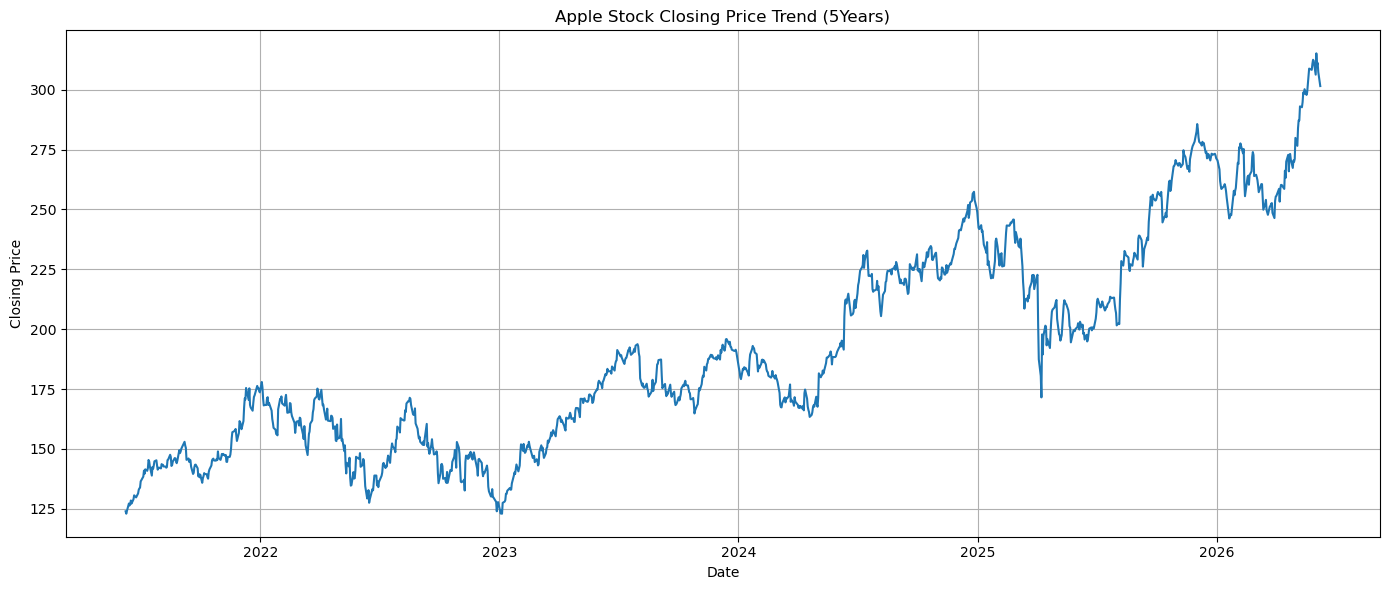

In [48]:
#Stock Price Closing Trend
import pandas as pd
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot (df.index, df['Close'])
plt.title('Apple Stock Closing Price Trend (5Years)')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.tight_layout()

plt.savefig('images/Stock_Price.png', dpi=300, bbox_inches = 'tight')
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

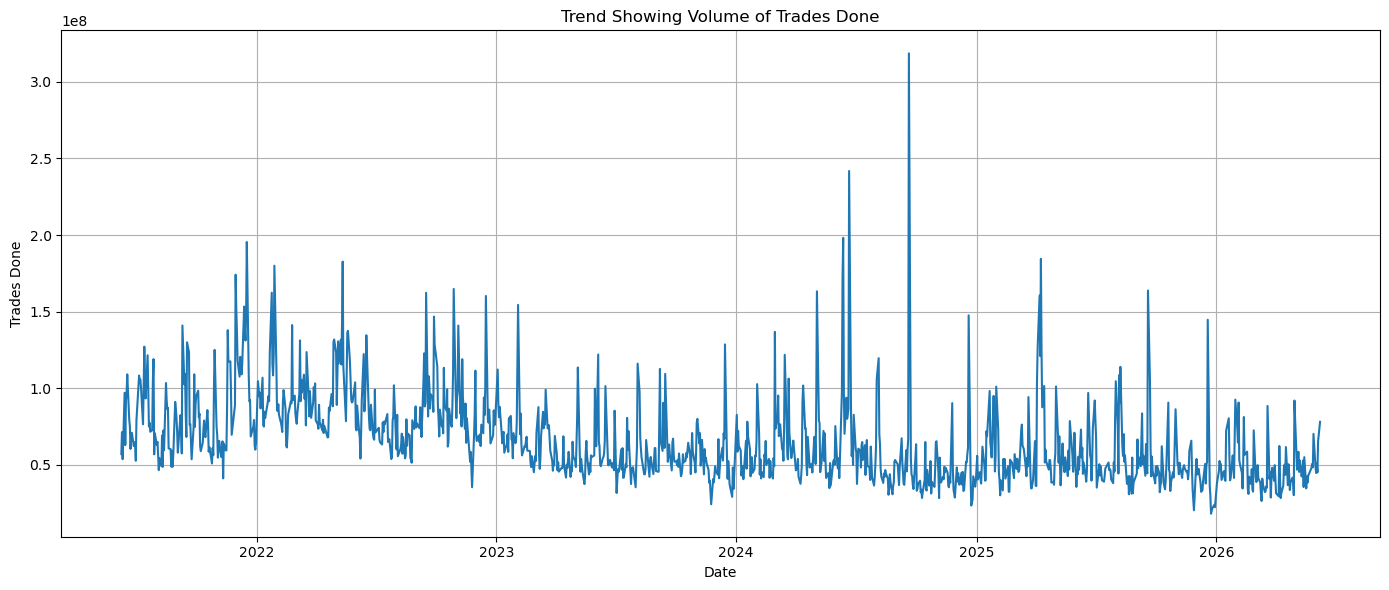

In [49]:
#Trading volume Trend
plt.figure(figsize=(14,6))
plt.plot(df.index,df['Volume'])
plt.title('Trend Showing Volume of Trades Done')
plt.xlabel('Date')
plt.ylabel('Trades Done')
plt.grid(True)
plt.tight_layout()
plt.savefig('images/Trading volume.png', dpi = 300, bbox_inches = 'tight')
plt.show

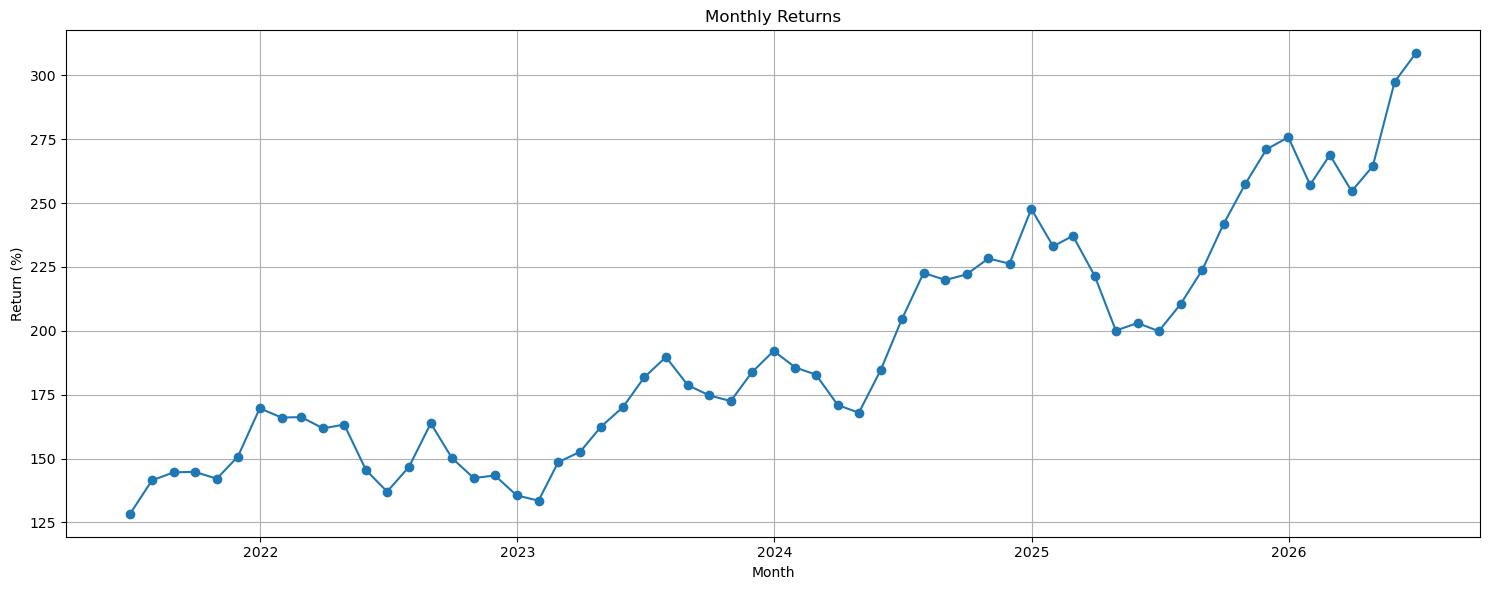

In [57]:
plt.figure(figsize=(15,6))

plt.plot(Monthly_Average.index,
         Monthly_Average.values,
         marker='o')

plt.title('Monthly Returns')
plt.xlabel('Month')
plt.ylabel('Return (%)')

plt.grid(True)

plt.tight_layout()
plt.savefig('images/Monthly Returns.png',  dpi=300, bbox_inches ='tight')
plt.show()

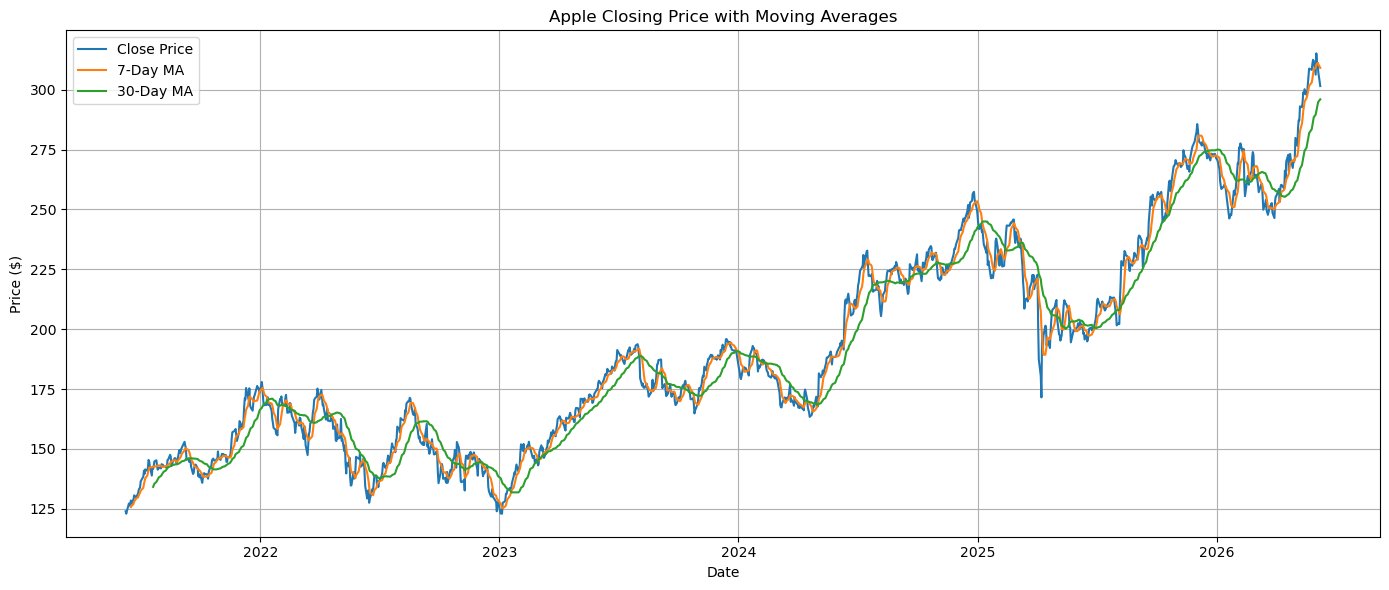

In [56]:
#Moving Average Analysis
plt.figure(figsize=(14,6))

plt.plot(df.index, df['Close'], label='Close Price')
plt.plot(df.index, df['7-Day MA'], label='7-Day MA')
plt.plot(df.index, df['30-Day MA'], label='30-Day MA')

plt.title('Apple Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()

plt.grid(True)
plt.tight_layout()
plt.savefig('images/Moving Average.png', dpi=300, bbox_inches='tight')
plt.show()

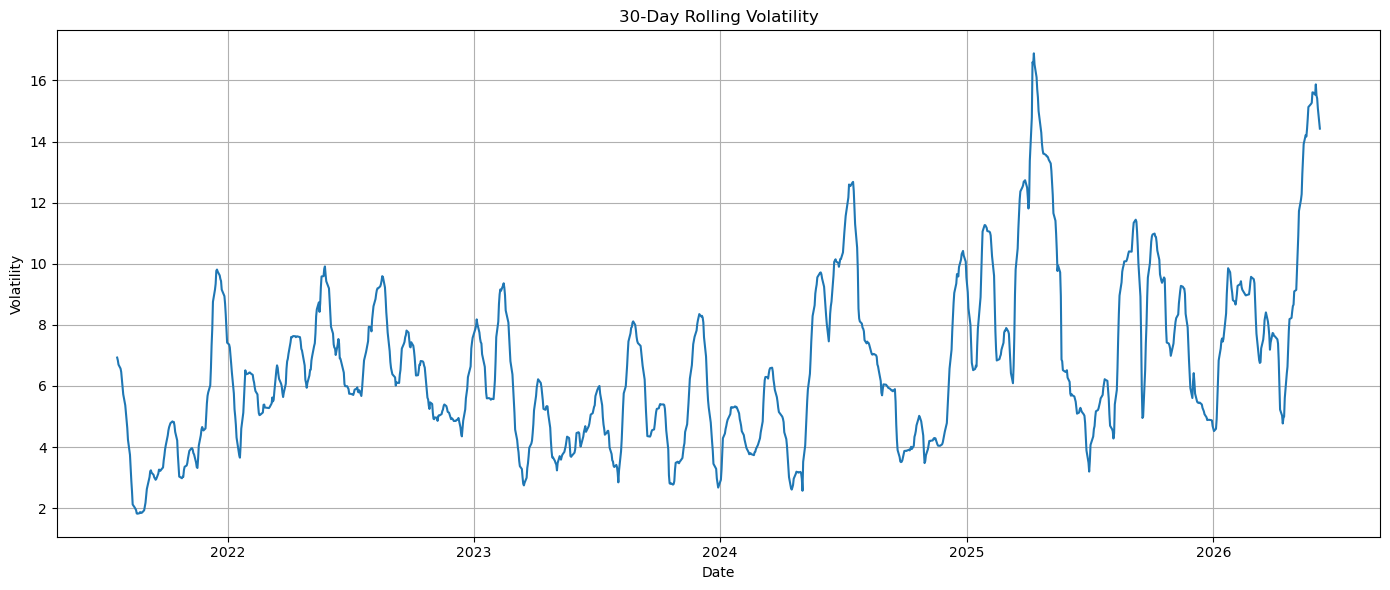

In [54]:
#Volatility
plt.figure(figsize=(14,6))

plt.plot(df.index,
         df['Volatility_30'])

plt.title('30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')

plt.grid(True)
plt.tight_layout()
plt.savefig('images/Volatility.png', dpi=300, bbox_inches='tight')
plt.show()

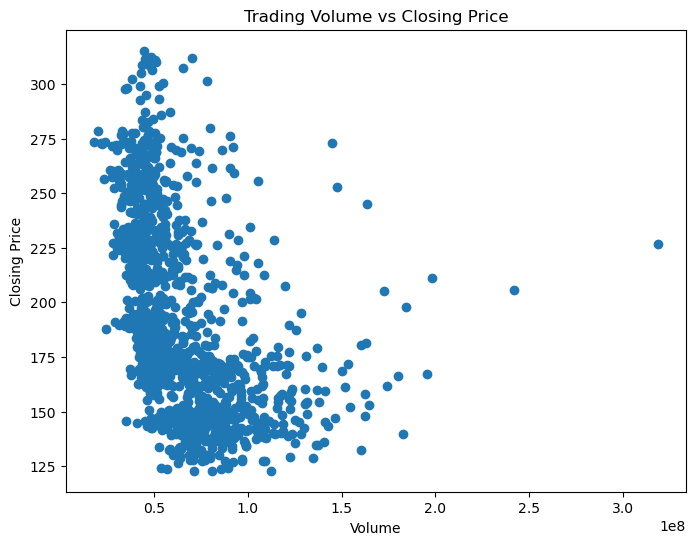

In [58]:
#useful relationship between variables
plt.figure(figsize=(8,6))

plt.scatter(df['Volume'],
            df['Close'])

plt.title('Trading Volume vs Closing Price')
plt.xlabel('Volume')
plt.ylabel('Closing Price')
plt.savefig('images/Tradingvsclosing.png', dpi = 300, bbox_inches='tight')

plt.show()

*KEY FINDINGS*
1. Minimum price in 2021,2022,2023 were $123 to $124.
2. No major price increase from 2021 to 2022.
3. Year 2022 experienced a -26% growth.
4. August and July has the lowest price in the years.
5. Poor daily returns but profitable yearly returns.
6. Periods with high volatility shows increased market uncertainty.
*CONCLUSION*
This analysis highlights how time-series techniques can transform historical financial data into actionable insights for investment analysis, business decision-making, and future predictive modeling.